In [371]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [372]:
pd.set_option('display.max_columns', None)

In [373]:
df = pd.read_csv('/content/AF_online_ecommerce_sales_dataset.csv', on_bad_lines = 'skip')

In [374]:
def data_organizer(df):
    df.drop_duplicates(inplace=True)

    # For this specific Dataset: I like Cleaner, Proper column names; so will Automate their Production
    if df.columns.str.contains('_').any():
        df.columns = [' '.join([word.capitalize() for word in col.split('_')]) for col in df.columns]
    numeric_cols = df.select_dtypes(include=['number']).columns  # Get numeric columns

    original_shape = df.shape

    # Crucial: Checking for non-Numeric Characters in Numeric columns
    for col in numeric_cols:
        invalid_rows = df[df[col].astype(str).str.contains(r'[^0-9.-]', na=False)].index
        if len(invalid_rows) > 0:  # If Invalid rows are found, Remove them
            df.drop(index=invalid_rows, inplace=True)

    print("The Original Dimensions of the DataFrame were:", original_shape)
    print("")
    print("""Dimensions of the DataFrame after Removing Non-Numeric Characters
          are:""", df.shape)
    print("")

    # I would like to see how many remaining Rows we have in the Dataset which contain any NULL value
    print(f"""The Dimensions of the Instances of the DataFrame containing any NULL value are: {df[df.isnull().any(axis=1)].shape}
          and the Columns that Contain any NULL Values are: {df.columns[df.isnull().any()].tolist()}""")

    print("")

    # Now, after this Preliminary "Organizing" (It was not Cleaned as much as was Processed for Future Cleaning), what are the Dataset's Details like?
    print(df.info())

Also, notice I have only Intended to Firstly see the Amount of Rows we have containing NULLs, only.
I have not Removed them yet as I would first like to Review them and then see if I have to Remove or Replace the NULL values

In [375]:
data_organizer(df)

The Original Dimensions of the DataFrame were: (533000, 29)

Dimensions of the DataFrame after Removing Non-Numeric Characters
          are: (533000, 29)

The Dimensions of the Instances of the DataFrame containing any NULL value are: (763, 29)
          and the Columns that Contain any NULL Values are: ['Employee Skill', 'Employee Education']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 533000 entries, 0 to 532999
Data columns (total 29 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Tmstmp               533000 non-null  object 
 1   Product Category     533000 non-null  object 
 2   Product Subcategory  533000 non-null  object 
 3   Product              533000 non-null  object 
 4   Brand Name           533000 non-null  object 
 5   Product Price        533000 non-null  float64
 6   Quantity Sold        533000 non-null  int64  
 7   Total Amount         533000 non-null  float64
 8   Total Costs          53300

In [376]:
# All Instances of NULL Values in the Dataset; they are all either in the "Employee Skill" or "Employee Education" columns

# df[df.isnull().any(axis = 1)]
df.isnull().sum()

,0
Tmstmp,0
Product Category,0
Product Subcategory,0
Product,0
Brand Name,0
Product Price,0
Quantity Sold,0
Total Amount,0
Total Costs,0
Payment Type,0


In [377]:
df[["Employee Skill", "Employee Education"]].value_counts()

# These columns do have fine Values for non-NULLs, but I do not believe we will be using them much
# I could just Remove the NULLs, but I will keep them for now as I might want to Visualize or build an ML predicting on Employee Skill/Education

,,count
Employee Skill,Employee Education,
Oversight,Shenyang University,2363
Java Enterprise Edition,Fachhochschulstudiengänge Steyr,2359
Corporate Governance,Technische Universität Dresden,2353
DVCProHD,Lampang College of Commerce and Technology,2351
Urology,Universidad Autónoma Metropolitana - Azcapotzalco,2348
...,...,...
MMIC,Capital University of Medical Sciences,2154
JVM,University of Applied Sciences Aargau,2143
Avid Newscutter,Zanjan University of Medical Sciences,2138


In [378]:
# Also, defining Functions to convert however many columns to the Desired Data Types, respectively

def str_maker(df, *cols):
  for i in cols:
    df[i] = df[i].astype(str)

def num_maker(df, *cols):
  for i in cols:
    df[i] = pd.to_numeric(df[i])

In [379]:
str_maker(df, "Customer Phone")

# df.dtypes # There we go!

## EDA: Advanced Data Analysis & Visualization

In [380]:
# All Numeric columns
df_num = df.select_dtypes(include = ['number'])

Summary Statistics for Online American Football Merchandise Sales:
       Product Price  Quantity Sold  Total Amount  Total Costs  \
count      533000.00      533000.00     533000.00    533000.00   
mean           77.47           5.50        404.63       170.14   
std           105.29           2.87        657.60       275.67   
min             1.99           1.00          1.64         0.82   
25%            15.91           3.00         62.69        26.60   
50%            42.08           6.00        177.63        75.12   
75%            89.05           8.00        440.74       185.76   
max           800.95          10.00       8007.40      3203.30   

       Coupon Discount  Customer Age  
count        533000.00     533000.00  
mean              4.98         29.01  
std               8.16          7.79  
min               0.00         16.00  
25%               0.00         22.00  
50%               0.00         29.00  
75%              10.00         36.00  
max              25.00    

<Figure size 800x700 with 0 Axes>

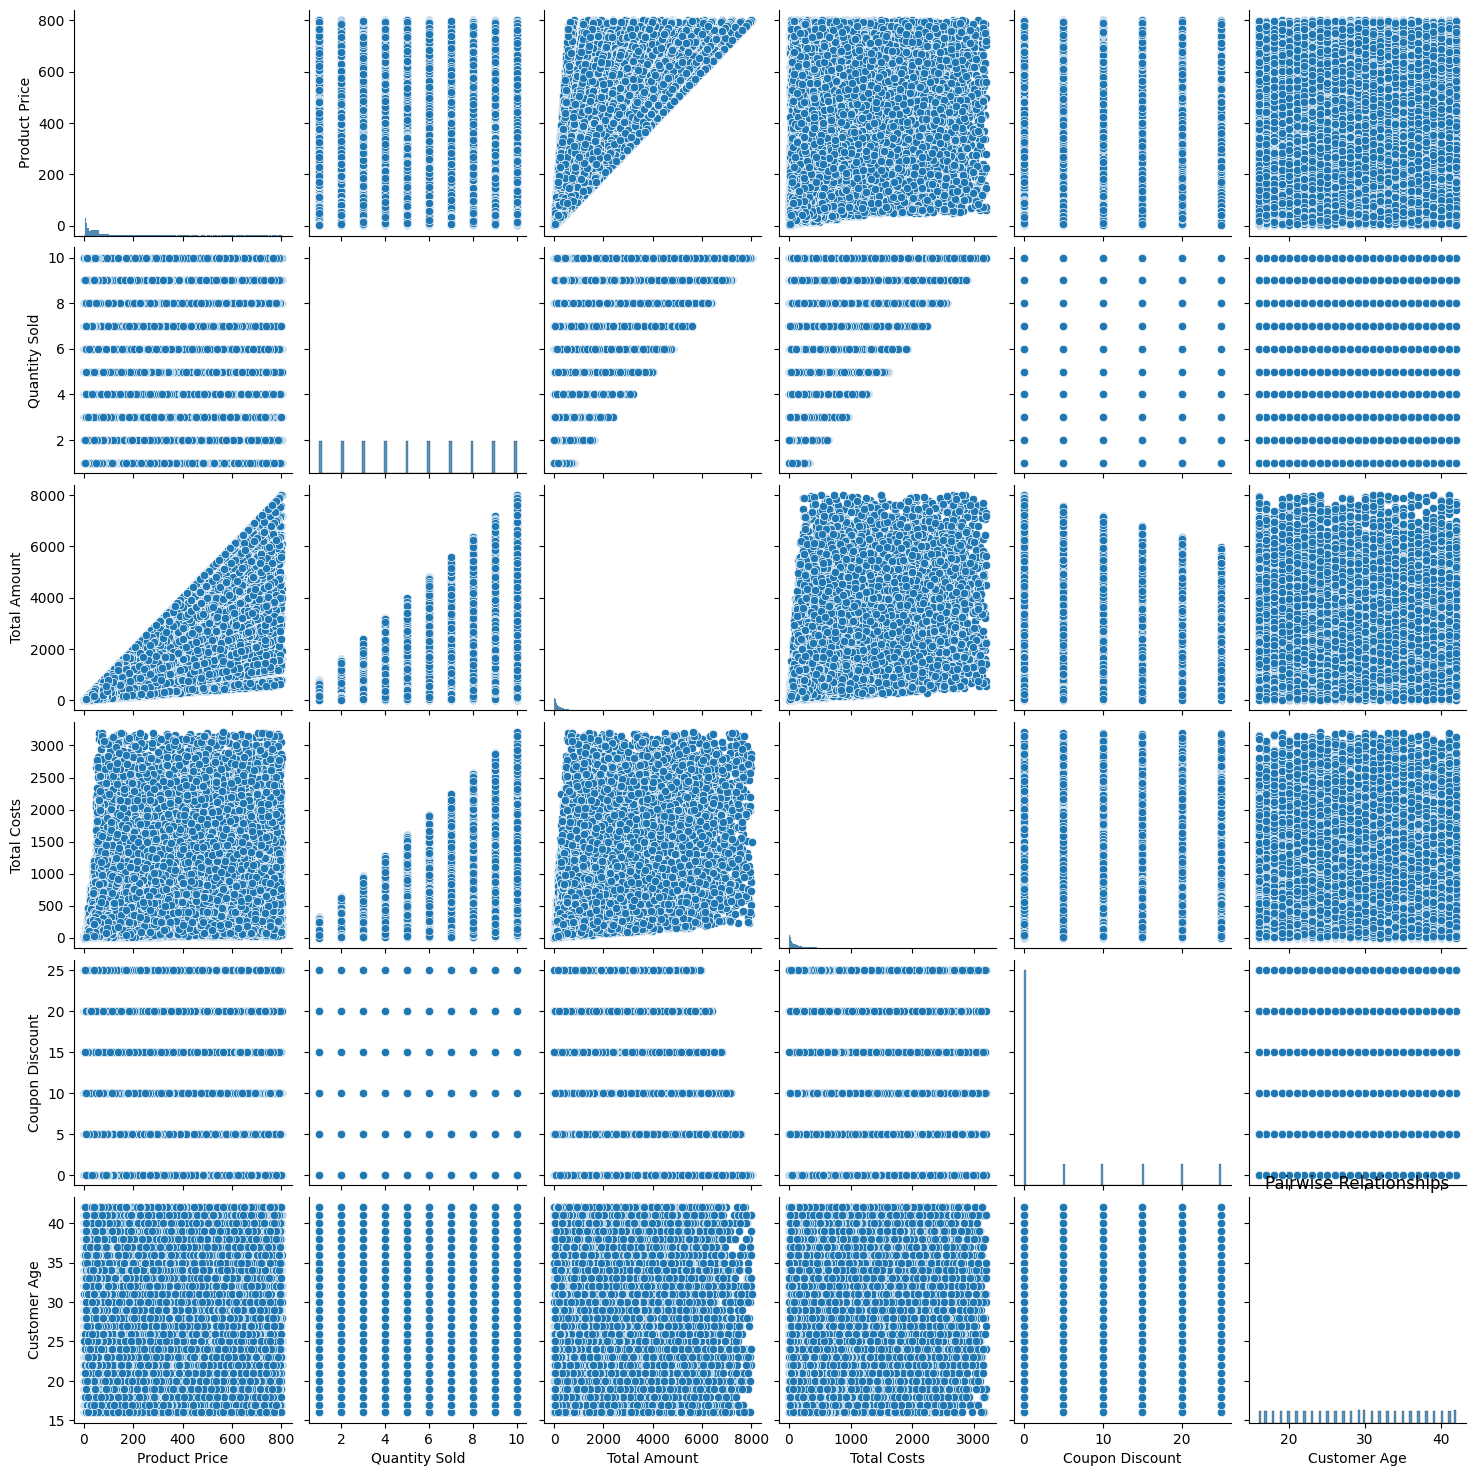

In [381]:
print("Summary Statistics for Online American Football Merchandise Sales:")
print(df.describe().round(2))
print("")

# Pairplots for all Numeric variables in the Dataset
## df_num = df.select_dtypes(include = ['number'])
plt.figure(figsize = (8, 7))
sns.pairplot(df_num)
plt.title("Pairwise Relationships")
plt.show()

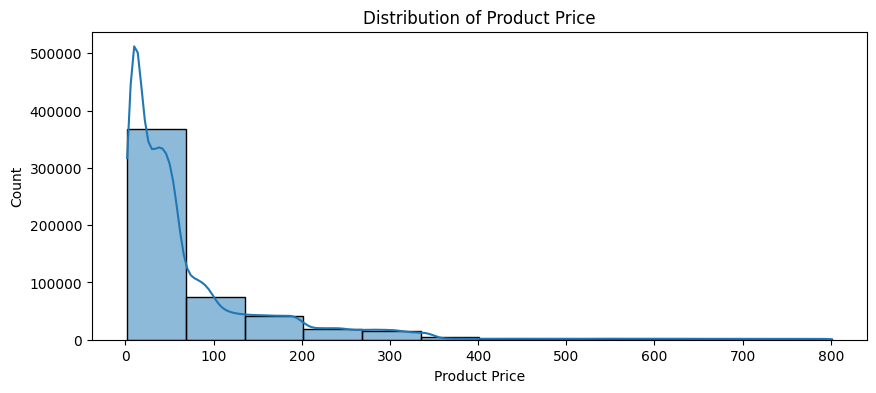

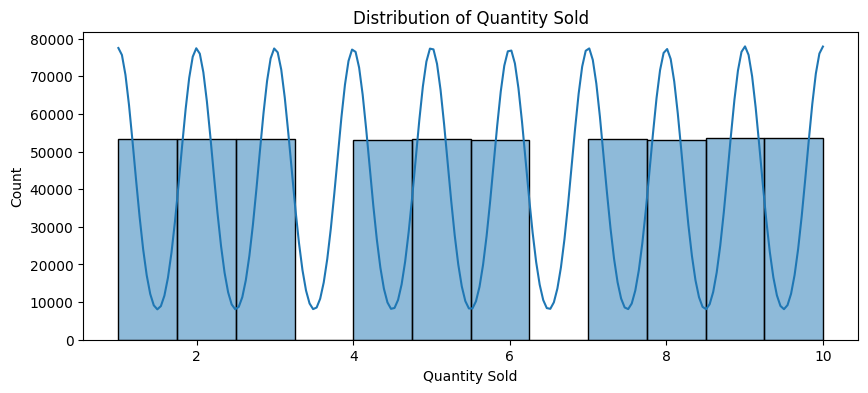

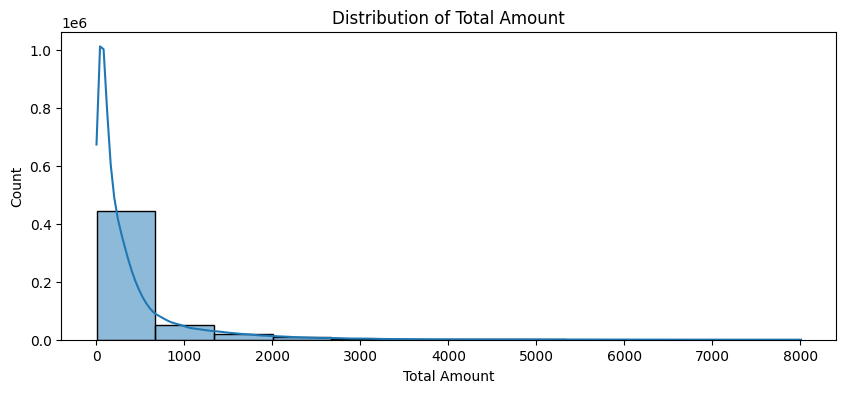

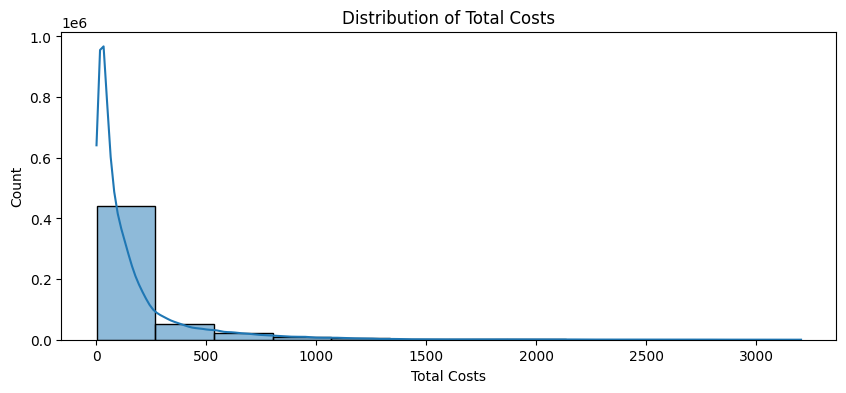

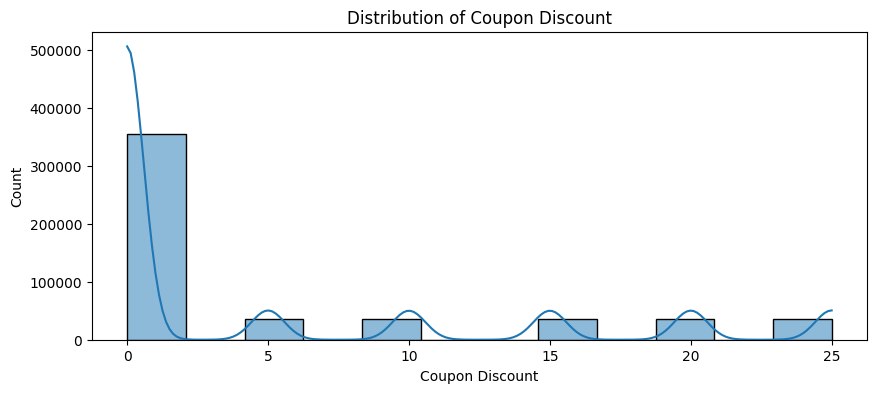

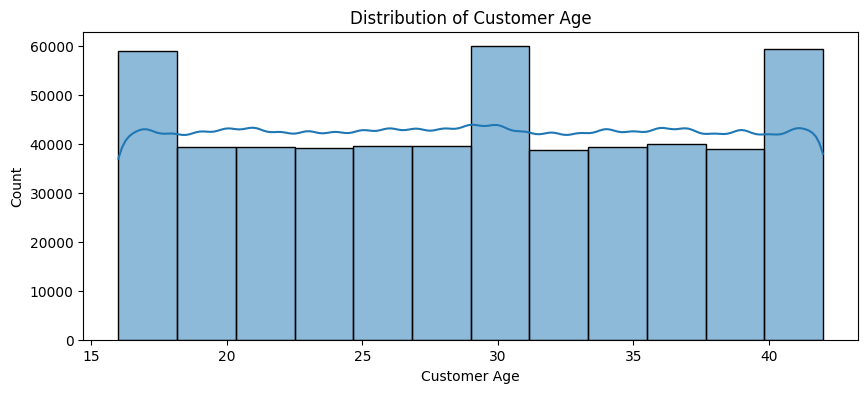

In [382]:
for i in df_num:
  plt.figure(figsize = (10, 4))
  sns.histplot(df[i], kde = True, bins = 12)
  plt.title(f"Distribution of {i}")
  plt.show() # None appears to be Normally Distributed

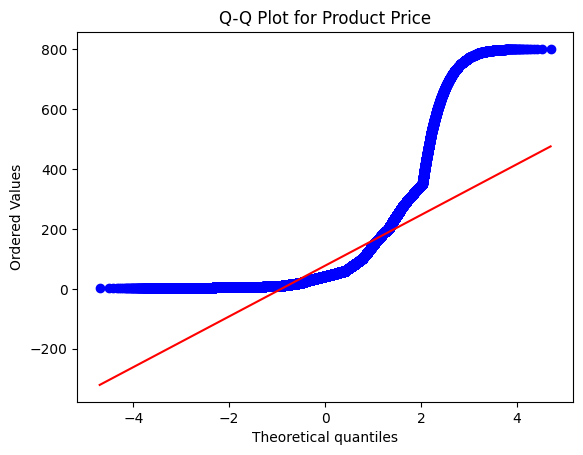

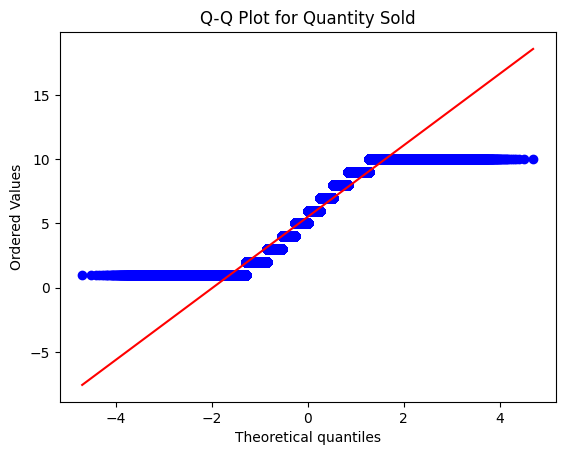

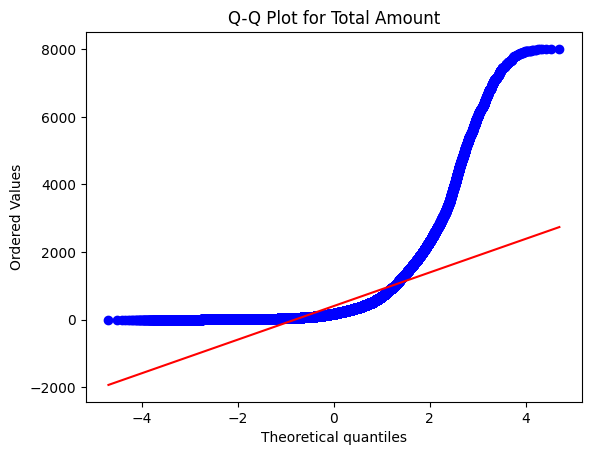

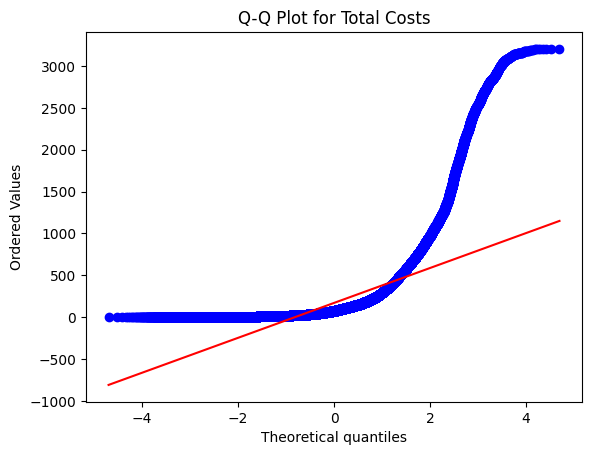

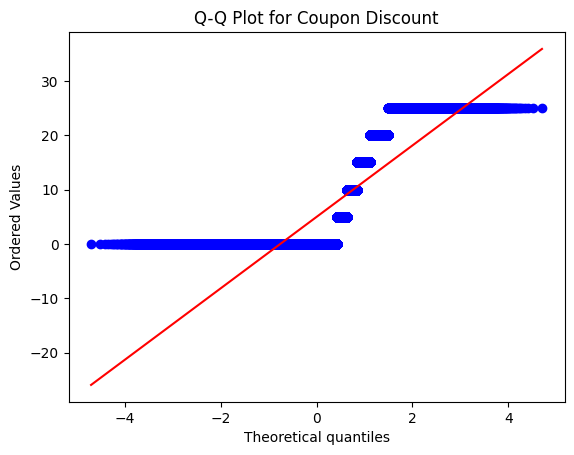

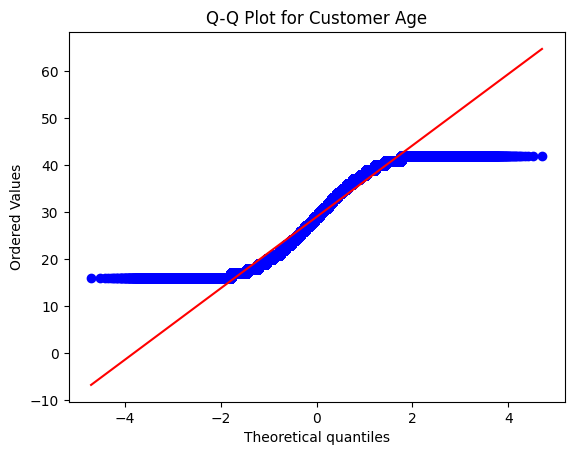

In [383]:
# Confirming with Q-Q Plots for each - Yes, None are Normally Distributed
import scipy.stats as stats

for i in df_num:
  stats.probplot(df[i], dist="norm", plot = plt)
  plt.title(f"Q-Q Plot for {i}")
  plt.show()

We should be able to go ahead and Remove Outliers with the IQR Method, but I want to check Boxplots, still.

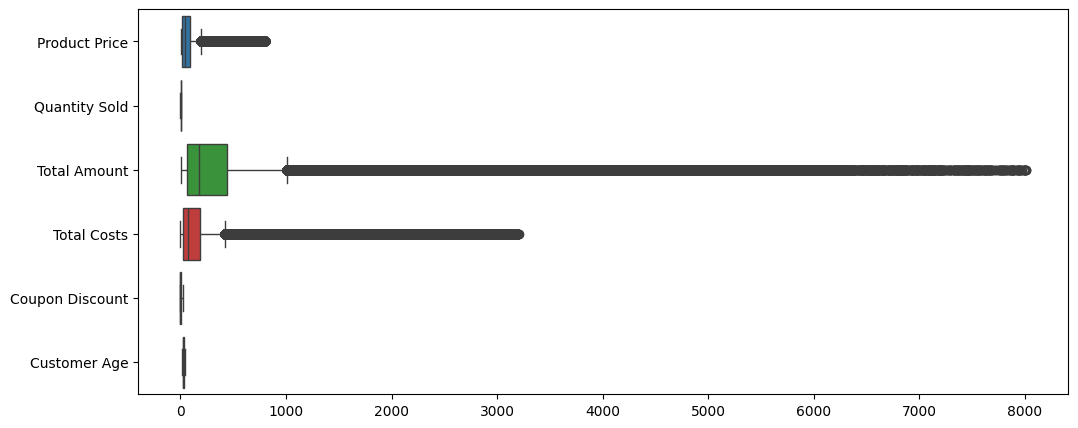

In [384]:
plt.figure(figsize = (12, 5))
sns.boxplot(df_num, orient = 'h')
plt.show()

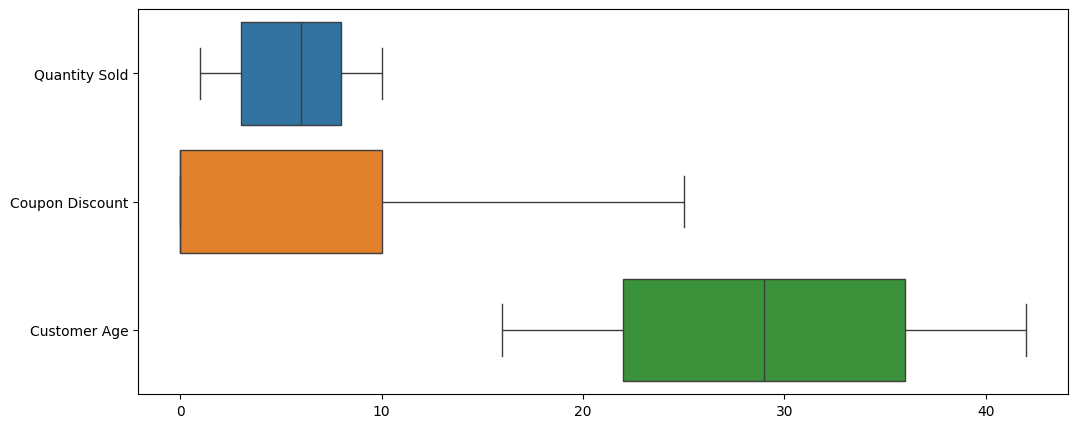

In [385]:
# 3 of the Columns are on a Drastically different scale of values; let's visualize them separately
plt.figure(figsize = (12, 5))
sns.boxplot(df_num[["Quantity Sold", "Coupon Discount", "Customer Age"]], orient = 'h')
plt.show()

I believe we should be good to go with the Removal of Outliers using the IQR Method except for the "Coupon Discount" column.

In [386]:
def remove_outliers_IQR(df, *cols):
  original_shape = df.shape
  for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

  print("The Original Dimensions of the DataFrame were:", original_shape)
  print("")
  print("Dimensions of the DataFrame after IQR-based Outlier Removal:", df.shape)

  return df

In [387]:
df_copy = df.copy()

remove_outliers_IQR(df_copy, 'Product Price', 'Quantity Sold', 'Total Amount', 'Total Costs', 'Customer Age')

# Ta-da! Done. Great.

The Original Dimensions of the DataFrame were: (533000, 29)

Dimensions of the DataFrame after IQR-based Outlier Removal: (419461, 29)


,Tmstmp,Product Category,Product Subcategory,Product,Brand Name,Product Price,Quantity Sold,Total Amount,Total Costs,Payment Type,Shipping Method,Coupon Discount,Customer Firstname,Customer Lastname,Customer Gender,Customer Age,Customer Shirtsize,Customer Email,Customer Phone,Customer Address,Address Details,Customer City,Customer State,Store Website,Employee Firstname,Employee Lastname,Employee Email,Employee Skill,Employee Education
0,2023-02-02 14:41:12,Protection,Padding,All Star KP2500 Small Adult Knee Pad (Pairs),All Star,18.69,5,93.45,23.85,credit card,DHL,0,Maribelle,Crickmer,Female,34,2XL,mcrickmer0@cbsnews.com,7045187192,810 Elgar Terrace,PO Box 62435,Charlotte,NC,helmetheroshop.com,Orelee,Curmi,povill5o@admin.ch,Rubber,Kardan University
1,2024-01-09 00:58:17,Footwear,Socks,Multi-Sport Sock,Champro,10.63,1,7.97,3.85,PayPal,USPS,25,Katerina,Baird,Female,28,XS,kbaird1@vkontakte.ru,7343341391,022 Cardinal Point,PO Box 88829,Detroit,MI,pigskinprovisions.com,Zeb,Absalom,crolingson3b@berkeley.edu,Live Events,National Taras Shevchenko University of Kiev
3,2023-10-30 23:03:56,Helmets,Face Masks,Riddell G2BDC (R74910),Riddell,46.55,1,46.55,19.94,credit card,DSV,0,Louie,Rowan,Male,22,M,lrowan3@about.com,7818111435,26 Sloan Avenue,16th Floor,Newton,MA,huddlehaven.com,Manya,Hilland,tisacq3c@shinystat.com,Print On Demand,Katholieke Hogeschool Limburg
4,2023-02-28 13:00:21,Helmets,Helmet Components,Riddell Speedflex Front Pad (R92400),Riddell,34.25,4,109.60,79.20,gift card,dpd,20,Eliot,Gullick,Male,19,S,egullick4@myspace.com,2127223081,51 Walton Drive,Suite 22,New York City,NY,spikestrategies.com,Giusto,Sporrij,hpoulsum2g@kickstarter.com,BST,European University at St.Petersburg
5,2022-03-09 14:44:58,Helmets,Helmet Components,Nike Gridiron Shield Clear,Nike,49.38,6,296.28,123.72,bank wire,USPS,0,Honoria,Doneld,Female,18,S,hdoneld5@soup.io,9017257199,70849 Graceland Avenue,Apt 1409,Memphis,TN,fieldforgefashions.com,Ardella,Edler,aliesj@freewebs.com,Simulations,Yonok University
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
532995,2022-06-07 22:27:53,Helmets,Helmet Components,Riddell Victor-I Inflation Bladder (R9122987),Riddell,41.48,9,373.32,209.43,PayPal,DHL,0,Roddy,Boncoeur,Male,41,L,ofiggern@nbcnews.com,5084300465,4747 Parkside Street,Suite 37,Worcester,MA,tackletownstore.com,Olvan,Figge,m08xd0@gmail.com,NaN,NaN
532996,2022-02-16 11:50:55,Helmets,Helmet Components,Rawlings FRNTBP Front Bumper,Rawlings,21.15,6,120.56,108.06,bank wire,DSV,5,Kev,Dymott,Male,33,3XL,hcowpertwaitro@elegantthemes.com,7025481796,489 Rutledge Crossing,Apt 645,North Las Vegas,NV,quarterbackquarters.com,Herve,Cowpertwait,847yya1s@hotmail.com,NaN,NaN
532997,2023-07-26 20:44:11,Protective Gear,Elbow,Rawlings FEPY Youth FTBL Elbow Pad,Rawlings,33.43,7,234.01,48.58,cash,dpd,0,Conan,Bramich,Male,26,L,dtreasurerp@example.com,7169241029,996 Northland Park,PO Box 31860,Buffalo,NY,endzoneexpress.com,Dun,Treasure,ziij94@gmail.com,NaN,NaN
532998,2022-10-03 00:30:15,Helmets,Helmet Maintenance,Riddell S-Bar HS4 Facemask Mounting Kit (R455914),Riddell,7.95,7,52.87,16.80,cash,DSV,5,Jemimah,Hills,Female,28,XS,dmeadmorerq@bluehost.com,6122286426,399 Kensington Circle,Apt 1856,Saint Paul,MN,helmetheroshop.com,Drusi,Meadmore,qam8y@hotmail.com,NaN,NaN


The Original Dimensions of the DataFrame were: (533000, 29)

Dimensions of the DataFrame after IQR-based Outlier Removal: (419461, 29)


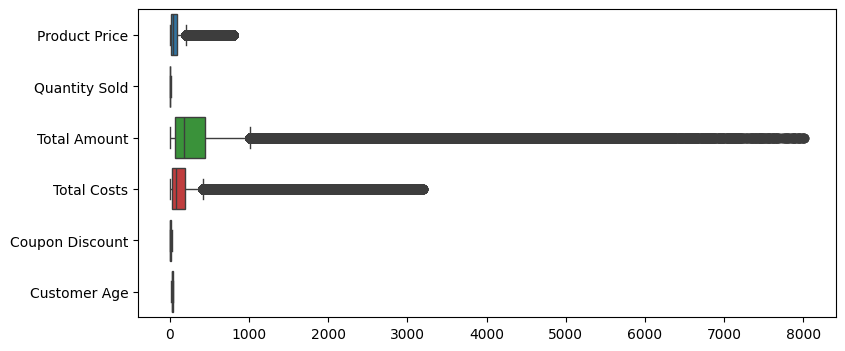

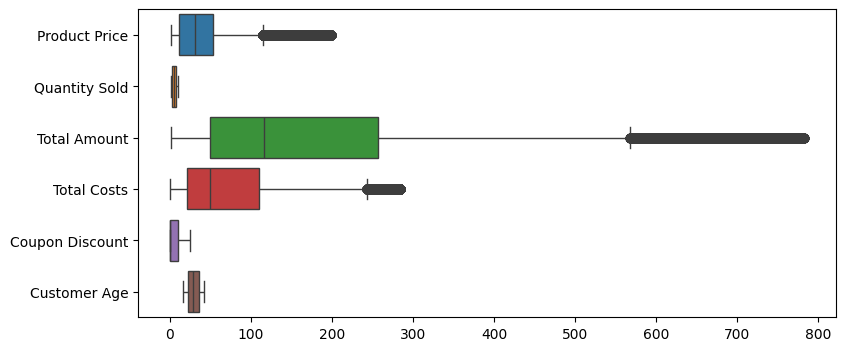

In [388]:
# Comparing Boxplots Prior to and After Outlier Removal

df_copy = remove_outliers_IQR(df_copy, 'Product Price', 'Quantity Sold', 'Total Amount', 'Total Costs', 'Customer Age')
df_num_copy = df_copy.select_dtypes(include = ['number'])

plt.figure(figsize = (9, 4))
sns.boxplot(df_num, orient = 'h')
plt.show()

plt.figure(figsize = (9, 4))
sns.boxplot(df_num_copy, orient = 'h')
plt.show()

There we go!^ Looks much better!

In [389]:
# Now that we can see it has worked fine & Compared the Boxplots, we can Remove Outliers on the main DataFrame and Continue with that

df = remove_outliers_IQR(df, 'Product Price', 'Quantity Sold', 'Total Amount', 'Total Costs', 'Customer Age')
df

The Original Dimensions of the DataFrame were: (533000, 29)

Dimensions of the DataFrame after IQR-based Outlier Removal: (419461, 29)


,Tmstmp,Product Category,Product Subcategory,Product,Brand Name,Product Price,Quantity Sold,Total Amount,Total Costs,Payment Type,Shipping Method,Coupon Discount,Customer Firstname,Customer Lastname,Customer Gender,Customer Age,Customer Shirtsize,Customer Email,Customer Phone,Customer Address,Address Details,Customer City,Customer State,Store Website,Employee Firstname,Employee Lastname,Employee Email,Employee Skill,Employee Education
0,2023-02-02 14:41:12,Protection,Padding,All Star KP2500 Small Adult Knee Pad (Pairs),All Star,18.69,5,93.45,23.85,credit card,DHL,0,Maribelle,Crickmer,Female,34,2XL,mcrickmer0@cbsnews.com,7045187192,810 Elgar Terrace,PO Box 62435,Charlotte,NC,helmetheroshop.com,Orelee,Curmi,povill5o@admin.ch,Rubber,Kardan University
1,2024-01-09 00:58:17,Footwear,Socks,Multi-Sport Sock,Champro,10.63,1,7.97,3.85,PayPal,USPS,25,Katerina,Baird,Female,28,XS,kbaird1@vkontakte.ru,7343341391,022 Cardinal Point,PO Box 88829,Detroit,MI,pigskinprovisions.com,Zeb,Absalom,crolingson3b@berkeley.edu,Live Events,National Taras Shevchenko University of Kiev
3,2023-10-30 23:03:56,Helmets,Face Masks,Riddell G2BDC (R74910),Riddell,46.55,1,46.55,19.94,credit card,DSV,0,Louie,Rowan,Male,22,M,lrowan3@about.com,7818111435,26 Sloan Avenue,16th Floor,Newton,MA,huddlehaven.com,Manya,Hilland,tisacq3c@shinystat.com,Print On Demand,Katholieke Hogeschool Limburg
4,2023-02-28 13:00:21,Helmets,Helmet Components,Riddell Speedflex Front Pad (R92400),Riddell,34.25,4,109.60,79.20,gift card,dpd,20,Eliot,Gullick,Male,19,S,egullick4@myspace.com,2127223081,51 Walton Drive,Suite 22,New York City,NY,spikestrategies.com,Giusto,Sporrij,hpoulsum2g@kickstarter.com,BST,European University at St.Petersburg
5,2022-03-09 14:44:58,Helmets,Helmet Components,Nike Gridiron Shield Clear,Nike,49.38,6,296.28,123.72,bank wire,USPS,0,Honoria,Doneld,Female,18,S,hdoneld5@soup.io,9017257199,70849 Graceland Avenue,Apt 1409,Memphis,TN,fieldforgefashions.com,Ardella,Edler,aliesj@freewebs.com,Simulations,Yonok University
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
532995,2022-06-07 22:27:53,Helmets,Helmet Components,Riddell Victor-I Inflation Bladder (R9122987),Riddell,41.48,9,373.32,209.43,PayPal,DHL,0,Roddy,Boncoeur,Male,41,L,ofiggern@nbcnews.com,5084300465,4747 Parkside Street,Suite 37,Worcester,MA,tackletownstore.com,Olvan,Figge,m08xd0@gmail.com,NaN,NaN
532996,2022-02-16 11:50:55,Helmets,Helmet Components,Rawlings FRNTBP Front Bumper,Rawlings,21.15,6,120.56,108.06,bank wire,DSV,5,Kev,Dymott,Male,33,3XL,hcowpertwaitro@elegantthemes.com,7025481796,489 Rutledge Crossing,Apt 645,North Las Vegas,NV,quarterbackquarters.com,Herve,Cowpertwait,847yya1s@hotmail.com,NaN,NaN
532997,2023-07-26 20:44:11,Protective Gear,Elbow,Rawlings FEPY Youth FTBL Elbow Pad,Rawlings,33.43,7,234.01,48.58,cash,dpd,0,Conan,Bramich,Male,26,L,dtreasurerp@example.com,7169241029,996 Northland Park,PO Box 31860,Buffalo,NY,endzoneexpress.com,Dun,Treasure,ziij94@gmail.com,NaN,NaN
532998,2022-10-03 00:30:15,Helmets,Helmet Maintenance,Riddell S-Bar HS4 Facemask Mounting Kit (R455914),Riddell,7.95,7,52.87,16.80,cash,DSV,5,Jemimah,Hills,Female,28,XS,dmeadmorerq@bluehost.com,6122286426,399 Kensington Circle,Apt 1856,Saint Paul,MN,helmetheroshop.com,Drusi,Meadmore,qam8y@hotmail.com,NaN,NaN


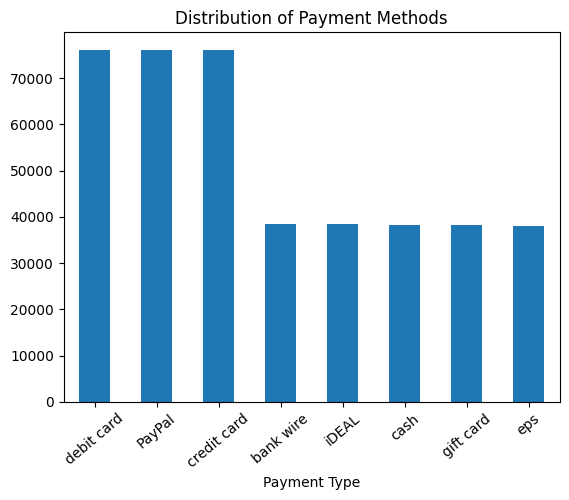

In [390]:
df["Payment Type"].value_counts().plot(kind = "bar")
plt.title("Distribution of Payment Methods")
plt.xticks(rotation = 40)
plt.show()

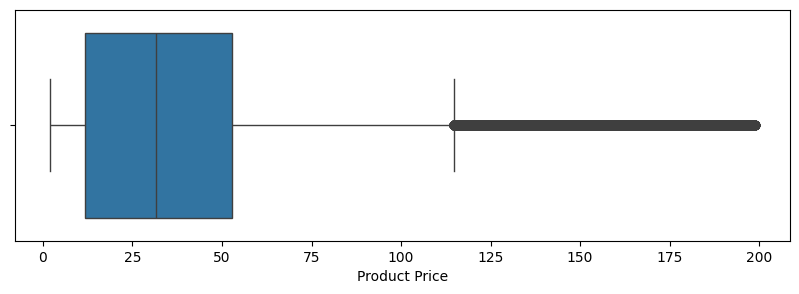

In [391]:
plt.figure(figsize = (10, 3))
sns.boxplot(df["Product Price"], orient = 'h')
plt.show()

### **Binning** Price Ranges

In [392]:
# df.head(5)

price_bins = [df["Product Price"].min()-1, df["Product Price"].quantile(0.25), df["Product Price"].median(), df["Product Price"].quantile(0.75), df["Product Price"].max()+1]
price_labels = ["Affordable", "Normal", "Expensive", "Very Expensive"]

df["Price Category"] = pd.cut(df["Product Price"], bins = price_bins, labels = price_labels)

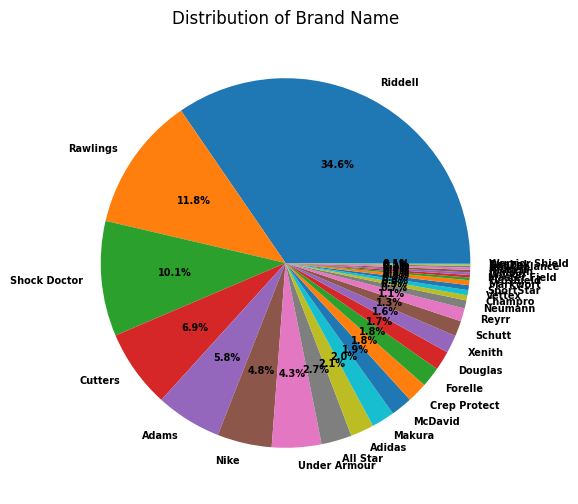

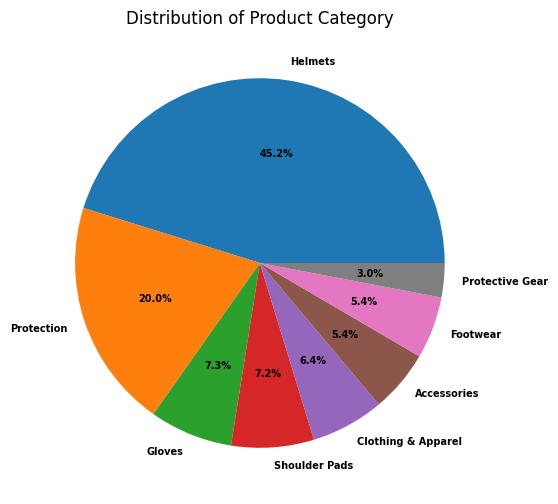

In [393]:
# Make a Pie Chart for each to see which Brands and Categories dominate sales
# Then, will One-Hot encode them and use them to build ML models to Predict Sales from them - can K-Means Cluster them as well as Lin Reg
brand_counts = df["Brand Name"].value_counts(normalize = True)
category_counts = df["Product Category"].value_counts(normalize = True)

for column_name, counts in [("Brand Name", brand_counts), ("Product Category", category_counts)]:
  plt.figure(figsize = (11, 6))
  plt.pie(counts.values, labels = counts.index, autopct = "%1.1f%%", textprops = {'fontsize': 7, 'fontweight': 'bold'})
  plt.title(f"Distribution of {column_name}")
# plt.legend(counts.index, loc = 'upper right')
  plt.show()

In [394]:
# Saving the Cleaned and Refined DataFrame
# df.to_csv('online_sales.csv', index = False)

## Machine Learning Model: **Decision Tree**

In [349]:
df.head(4)

,Tmstmp,Product Category,Product Subcategory,Product,Brand Name,Product Price,Quantity Sold,Total Amount,Total Costs,Payment Type,Shipping Method,Coupon Discount,Customer Firstname,Customer Lastname,Customer Gender,Customer Age,Customer Shirtsize,Customer Email,Customer Phone,Customer Address,Address Details,Customer City,Customer State,Store Website,Employee Firstname,Employee Lastname,Employee Email,Employee Skill,Employee Education,Price Category
0,2023-02-02 14:41:12,Protection,Padding,All Star KP2500 Small Adult Knee Pad (Pairs),All Star,18.69,5,93.45,23.85,credit card,DHL,0,Maribelle,Crickmer,Female,34,2XL,mcrickmer0@cbsnews.com,7045187192,810 Elgar Terrace,PO Box 62435,Charlotte,NC,helmetheroshop.com,Orelee,Curmi,povill5o@admin.ch,Rubber,Kardan University,Normal
1,2024-01-09 00:58:17,Footwear,Socks,Multi-Sport Sock,Champro,10.63,1,7.97,3.85,PayPal,USPS,25,Katerina,Baird,Female,28,XS,kbaird1@vkontakte.ru,7343341391,022 Cardinal Point,PO Box 88829,Detroit,MI,pigskinprovisions.com,Zeb,Absalom,crolingson3b@berkeley.edu,Live Events,National Taras Shevchenko University of Kiev,Affordable
3,2023-10-30 23:03:56,Helmets,Face Masks,Riddell G2BDC (R74910),Riddell,46.55,1,46.55,19.94,credit card,DSV,0,Louie,Rowan,Male,22,M,lrowan3@about.com,7818111435,26 Sloan Avenue,16th Floor,Newton,MA,huddlehaven.com,Manya,Hilland,tisacq3c@shinystat.com,Print On Demand,Katholieke Hogeschool Limburg,Expensive
4,2023-02-28 13:00:21,Helmets,Helmet Components,Riddell Speedflex Front Pad (R92400),Riddell,34.25,4,109.60,79.20,gift card,dpd,20,Eliot,Gullick,Male,19,S,egullick4@myspace.com,2127223081,51 Walton Drive,Suite 22,New York City,NY,spikestrategies.com,Giusto,Sporrij,hpoulsum2g@kickstarter.com,BST,European University at St.Petersburg,Expensive


### Feature Engineering - One-Hot Encoding

Based on a Customer's Age and the Coupon Discount offered (if any) on the base price, what Price Category (base price, without Coupon Discount applied) of Product will a person buy?

In [396]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score as acc

X = df[["Customer Age", "Coupon Discount"]]
y = df["Price Category"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 10)

In [366]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

In [397]:
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [398]:
y_pred_dt = dt.predict(X_test)

acc_dt = round(acc(y_test, y_pred_dt)*100, 2)
print(round(acc(y_test, y_pred_dt)*100, 2), '%') # Not the Best Accuracy; However, it is still Insightful to Visualize the Decision Tree and get an idea

# The Nature of the Dataset does not Currently allow for Optimal Decision Tree Classifiers. So, the other Machine Learning models (Linear Regression, K-Means Clustering) in the project are fine.
# Will still do a Sample Prediction & Decision Tree Visualization for Project insights & Skill portrayal.

25.27 %


In [399]:
sample_sc = [[22, 5]]
print(dt.predict(sample_sc))

# Based on this Hypothetical Sample^, according to our Decision Tree Classifier, this Person will buy a Product Classified "Normal" in Base Price

['Normal']


**Visualizing the Decision Tree - with both Predictors together, and two also based on each Predictor separately:**

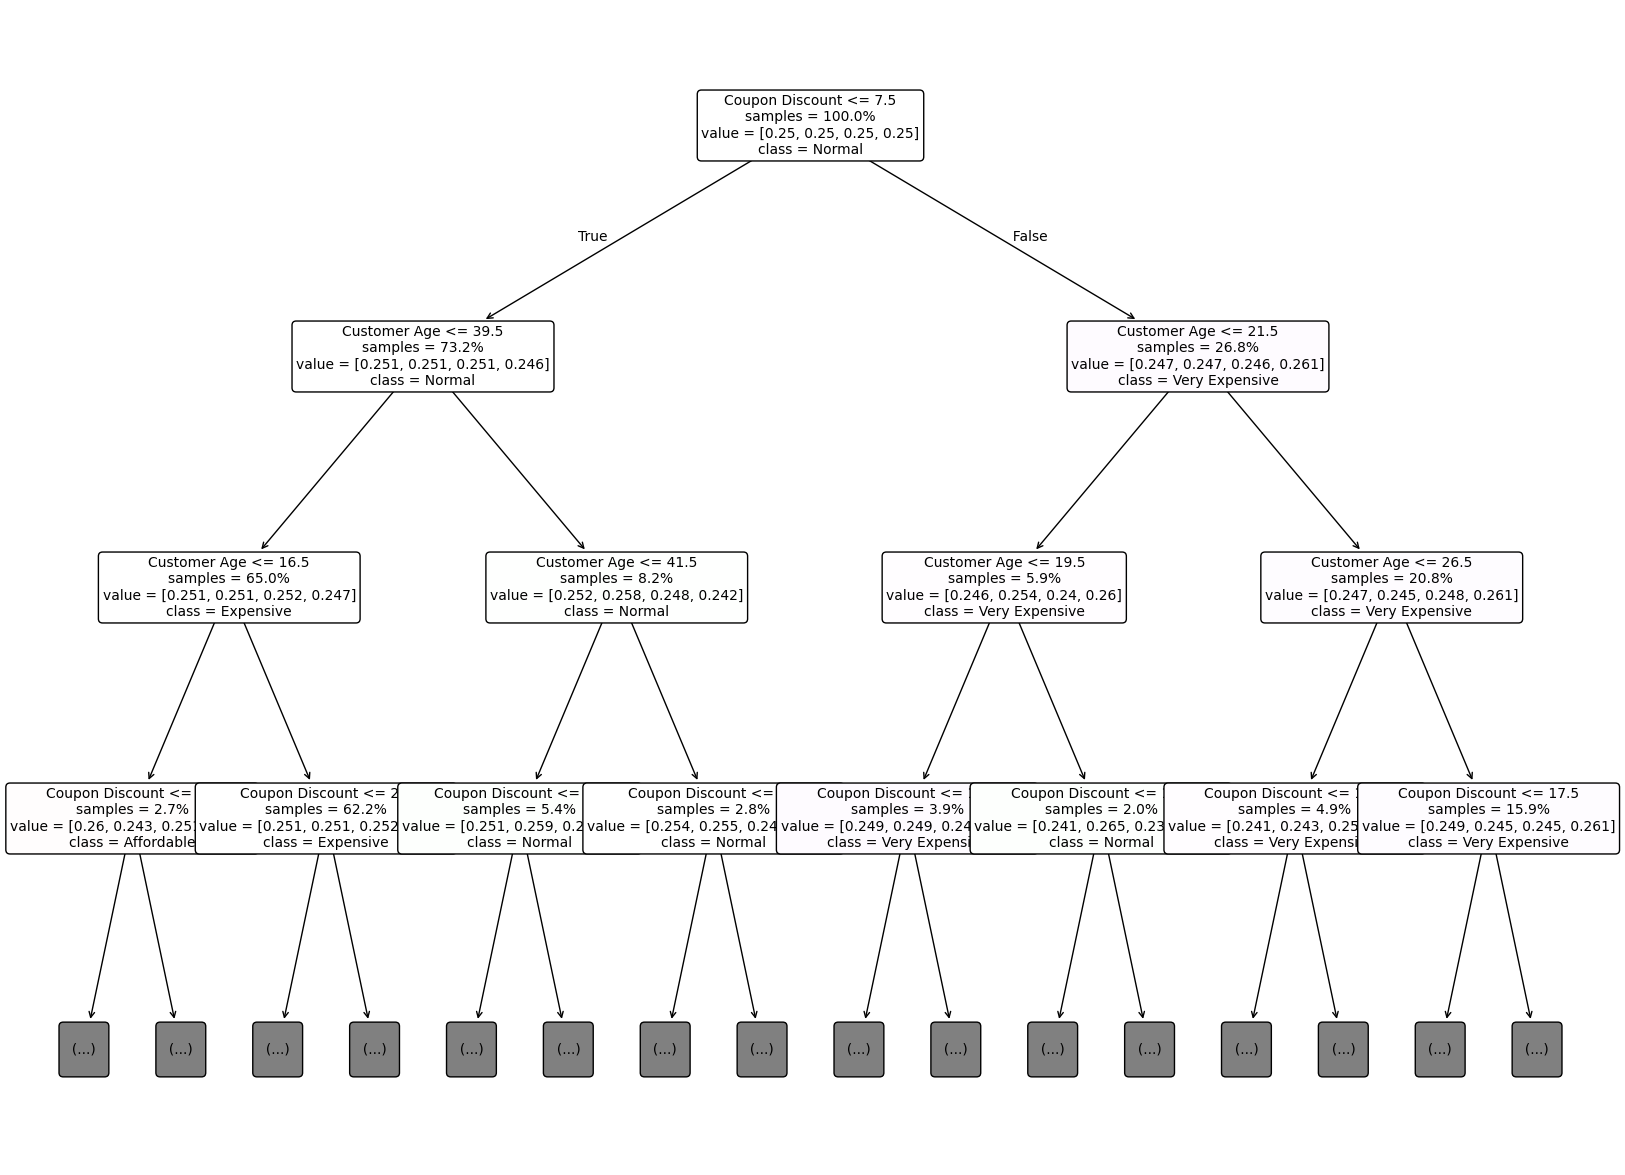

In [401]:
from sklearn import tree

fig = plt.figure(figsize=(20, 15))
_ = tree.plot_tree(dt,
                   feature_names = X_train.columns, # Properly Naming the Predictor Columns
                   class_names = ['Affordable', 'Normal', 'Expensive', 'Very Expensive'], # Naming the Predicted Outcomes
                   label = 'all',
                   filled = True,
                   fontsize = 10,
                   impurity = False,
                   node_ids = False,
                   proportion = True,
                   rounded = True,  # Adding rounded corners to boxes
                   max_depth = 3) # Limiting the Depth of the Tree displayed

plt.show()

Now, for the Separate Decision Tree Classifiers & Visualizations:

In [402]:
# Decision Tree using only Customer Age
dt_age = DecisionTreeClassifier()
dt_age.fit(X_train[["Customer Age"]], y_train)

# Decision Tree using only Coupon Discount
dt_discount = DecisionTreeClassifier()
dt_discount.fit(X_train[["Coupon Discount"]], y_train)

DecisionTreeClassifier()

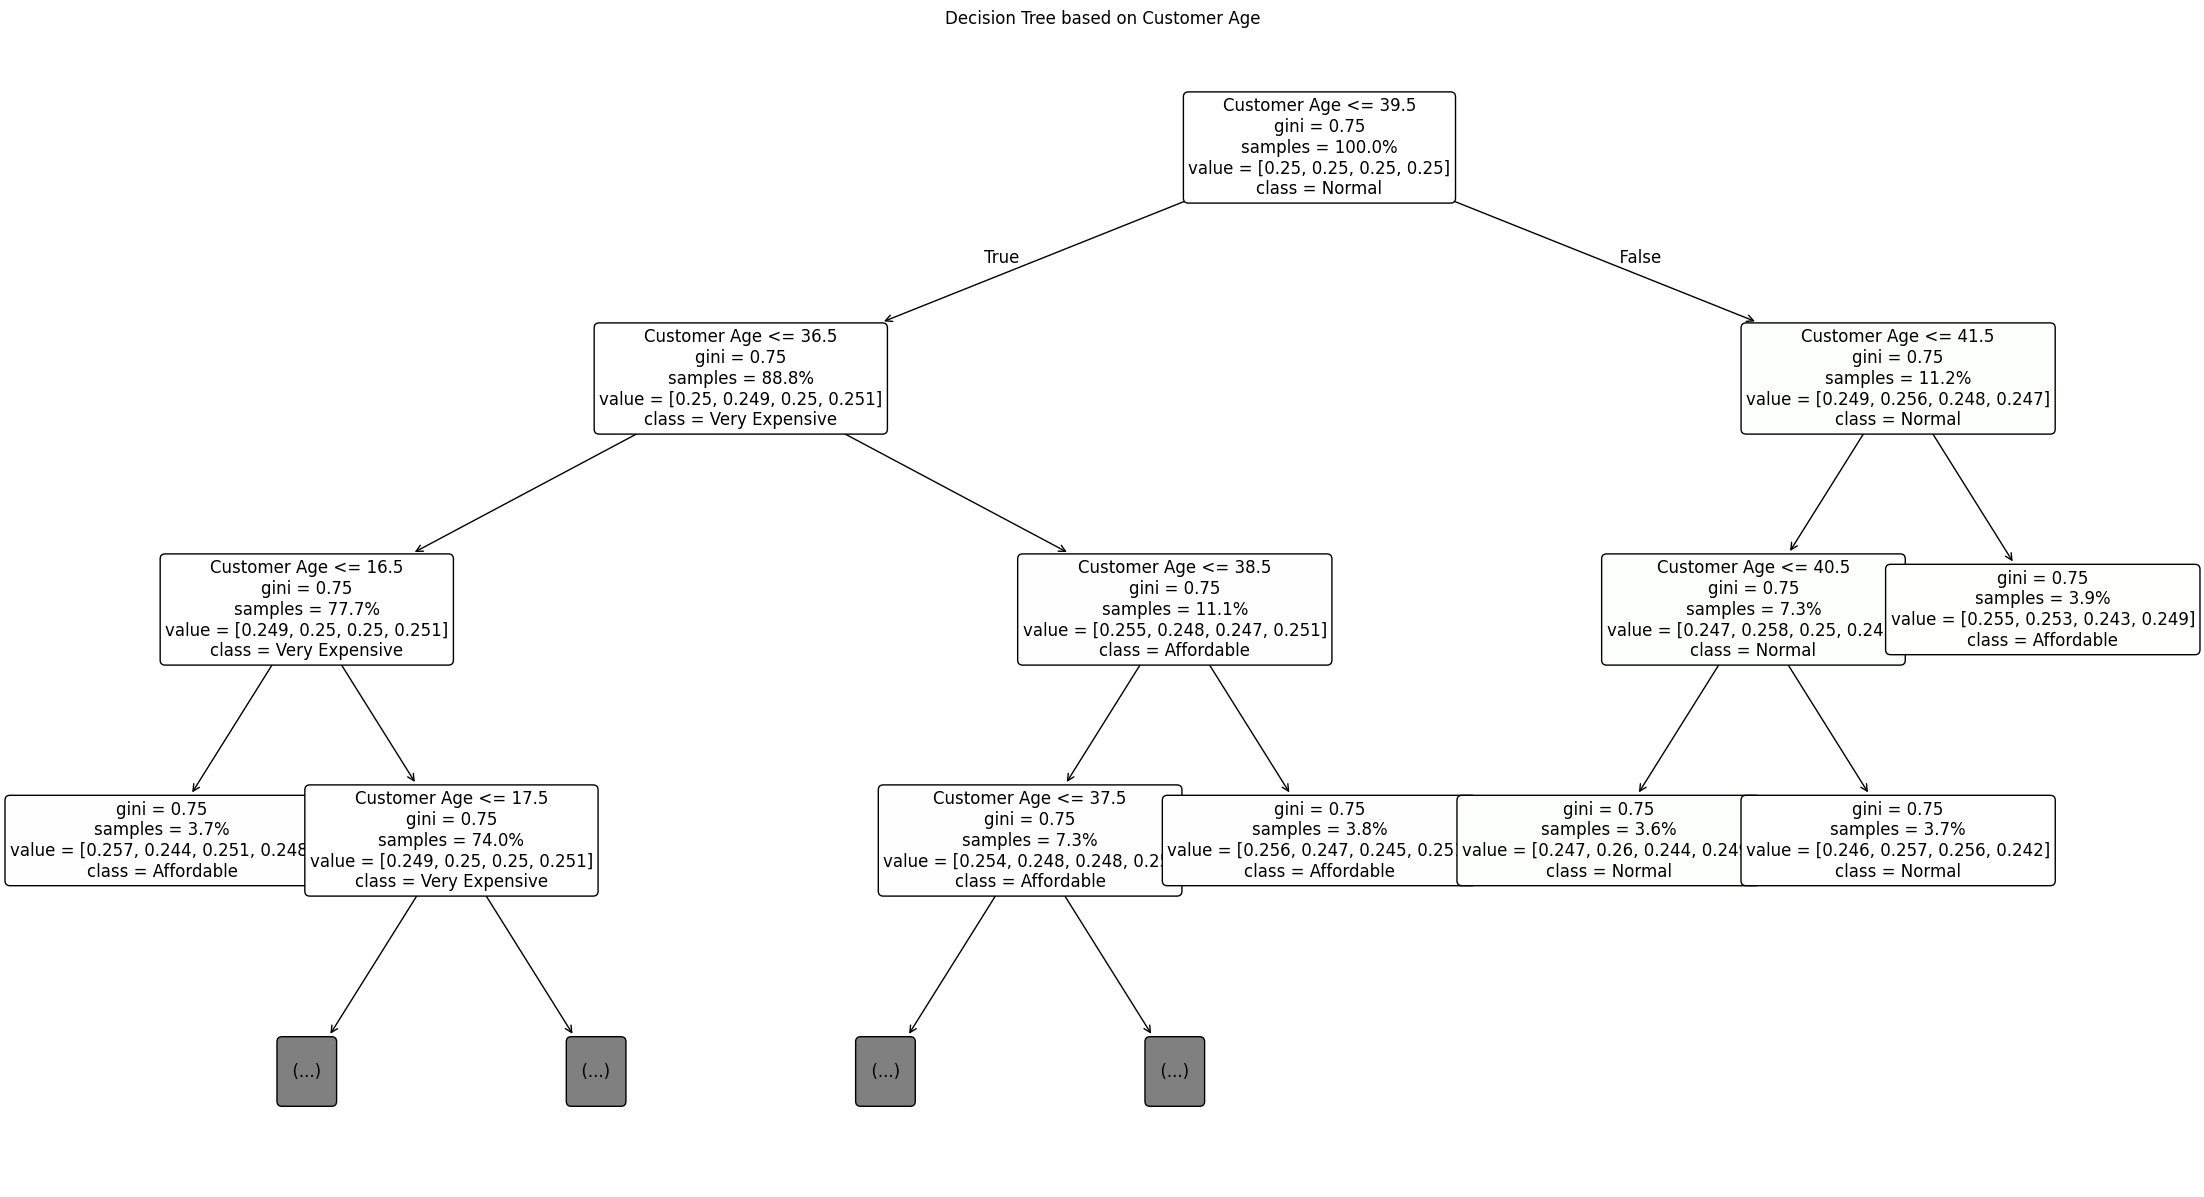

In [423]:
import matplotlib.pyplot as plt
from sklearn import tree

# Plot the 1st Tree (Customer Age)
plt.figure(figsize=(28, 15))
tree.plot_tree(dt_age,
               feature_names = ["Customer Age"],
               class_names = ['Affordable', 'Normal', 'Expensive', 'Very Expensive'],
               filled=True,
               rounded=True,
               fontsize = 12,
               proportion = True,
               max_depth = 3)

plt.title("Decision Tree based on Customer Age")

plt.show()

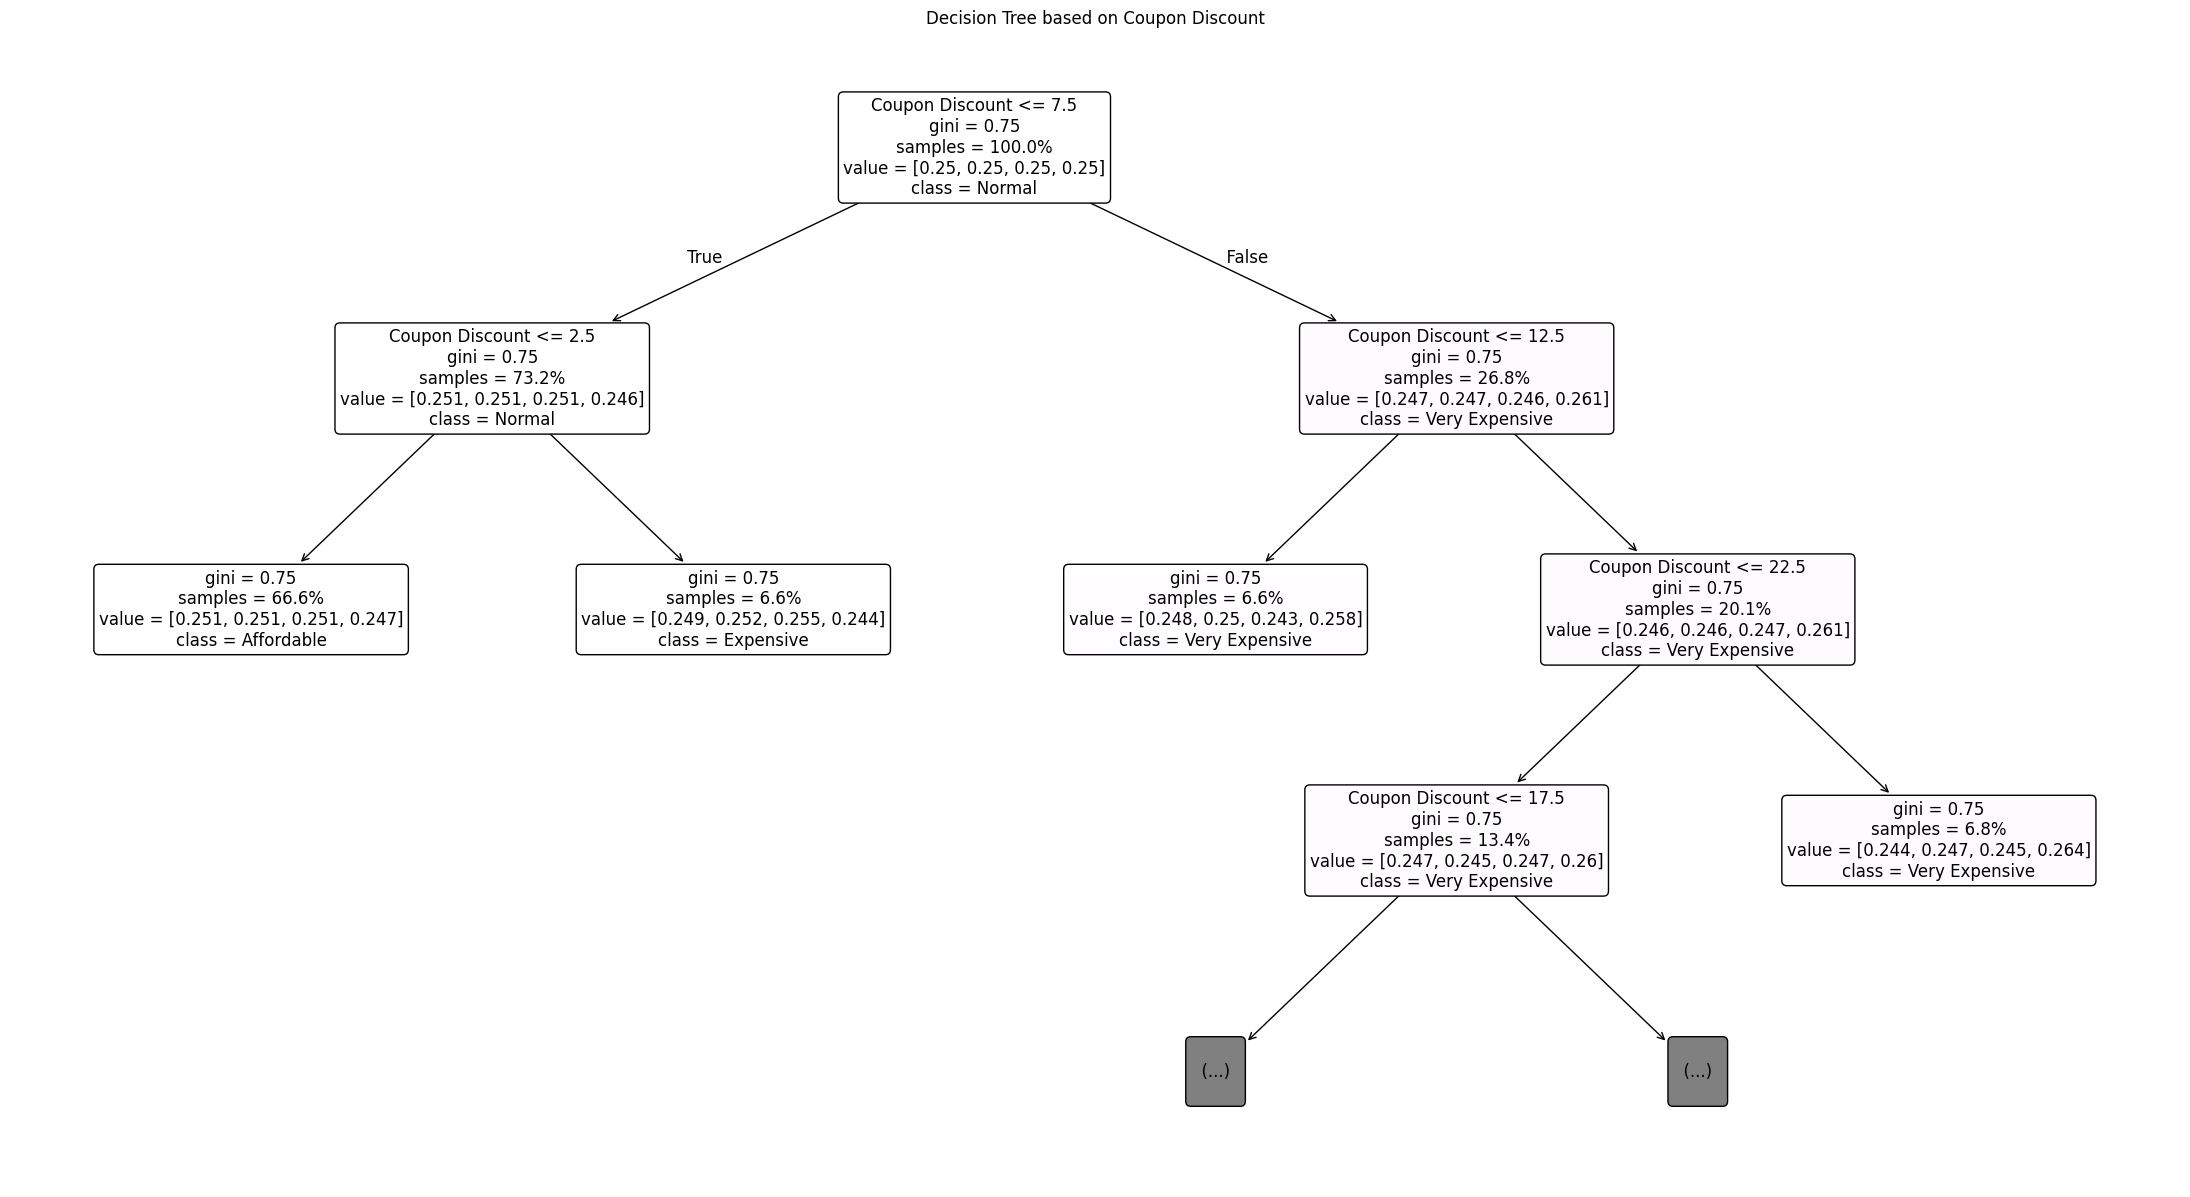

In [421]:
# Plotting the 2nd Tree (Coupon Discount)

plt.figure(figsize=(28, 15))
tree.plot_tree(dt_discount,
               feature_names = ["Coupon Discount"],
               class_names = ['Affordable', 'Normal', 'Expensive', 'Very Expensive'],
               filled=True,
               rounded=True,
               fontsize = 12,
               proportion = True,
               max_depth = 3)

plt.title("Decision Tree based on Coupon Discount")

plt.show()